# Task-1 Report: 基于机器学习的文本分类

## 与 request.md 对齐清单
- 使用 `new_train.tsv / new_test.tsv`，并从训练集切分验证集。
- 特征对照：`BoW` vs `N-gram`。
- 训练对照：不同损失函数（`CE/MSE`）与学习率。
- 结果可视化：表格 + 图表。

## 代码实现要点
- 数据读取与划分：`src/task1/data.py`
- BoW/N-gram 与 TF-IDF 向量化：`src/task1/vectorizer.py`
- 纯张量线性分类器（不调用 `torch.nn`）：`src/task1/model.py`
- mini-batch 训练、验证、测试与曲线输出：`src/task1/train.py`

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path('/home/df_05/A_fnlp/pytorch')

rows = []
for p in (ROOT / 'outputs/task1').glob('**/metrics.json'):
    cfg_p = p.parent / 'config.json'
    if not cfg_p.exists():
        continue
    m = json.loads(p.read_text(encoding='utf-8'))
    c = json.loads(cfg_p.read_text(encoding='utf-8'))
    rel = p.parent.relative_to(ROOT / 'outputs/task1')
    group = rel.parts[0] if len(rel.parts) > 1 else 'root'
    rows.append({
        'run': p.parent.name,
        'group': group,
        'feature_mode': c.get('feature_mode'),
        'loss': c.get('loss'),
        'lr': c.get('lr'),
        'ngram_n': c.get('ngram_n'),
        'tfidf': bool(c.get('tfidf', False)),
        'normalize': bool(c.get('normalize', False)),
        'vocab_size': m.get('vocab_size'),
        'best_val_acc': m.get('best_val_acc'),
        'test_acc': m.get('test_acc'),
        'path': str(p.parent),
    })
df = pd.DataFrame(rows).sort_values('test_acc', ascending=False).reset_index(drop=True)
display(df[['run','group','feature_mode','loss','lr','tfidf','normalize','best_val_acc','test_acc']].head(20))
best_row = df.iloc[0]
print('Best run:', best_row['run'], 'test_acc=', round(float(best_row['test_acc']), 4))

,run,group,feature_mode,loss,lr,tfidf,normalize,best_val_acc,test_acc
0,best_ngram2_ce_lr01_30k,best,ngram,ce,0.1,False,True,0.355217,0.371411
1,best_bow_ce_lr01,best,bow,ce,0.1,False,True,0.356389,0.370202
2,best_bow_ce_lr02_30k,best,bow,ce,0.2,False,True,0.355217,0.369900
3,exp_02_ngram_ce_lr0.5,root,ngram,ce,0.5,False,False,0.354045,0.367785
4,best_ngram2_tfidf_ce_lr02,best,ngram,ce,0.2,True,False,0.355217,0.367785
5,exp_01_bow_ce_lr0.5,root,bow,ce,0.5,False,False,0.344666,0.363554
6,best_ngram2_tfidf_ce_lr01_40k,best,ngram,ce,0.1,True,False,0.356389,0.357208
7,best_bow_tfidf_ce_lr02,best,bow,ce,0.2,True,False,0.343494,0.350257
8,exp_02_bow_ce_lr0.2,final,bow,ce,0.2,False,True,0.336460,0.332125
9,exp_06_ngram_ce_lr0.2,final,ngram,ce,0.2,False,True,0.332943,0.320338


Best run: best_ngram2_ce_lr01_30k test_acc= 0.3714


,feature_mode,test_acc
1,ngram,0.371411
0,bow,0.370202


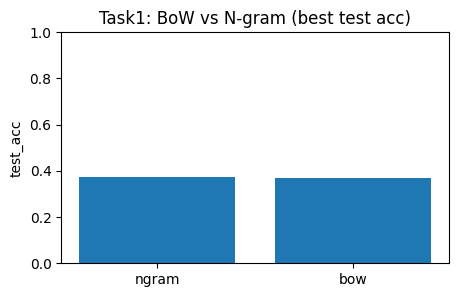

In [2]:
# 1) BoW vs N-gram
df_base = df[(df['loss'] == 'ce') & (df['group'].isin(['final','best']))]
cmp = df_base.groupby('feature_mode', as_index=False)['test_acc'].max().sort_values('test_acc', ascending=False)
display(cmp)
plt.figure(figsize=(5,3))
plt.bar(cmp['feature_mode'], cmp['test_acc'])
plt.ylim(0.0, 1.0)
plt.title('Task1: BoW vs N-gram (best test acc)')
plt.ylabel('test_acc')
plt.show()

lr,0.2,0.5
loss,,
ce,0.332125,0.315805
mse,0.315805,0.312481


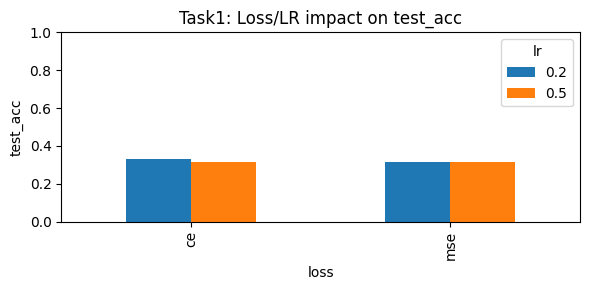

In [3]:
# 2) 不同损失函数 + 学习率
df_grid = df[df['group'] == 'final'].copy()
pivot = df_grid.pivot_table(index='loss', columns='lr', values='test_acc', aggfunc='max')
display(pivot)
ax = pivot.plot(kind='bar', figsize=(6,3))
ax.set_ylim(0.0, 1.0)
ax.set_title('Task1: Loss/LR impact on test_acc')
ax.set_ylabel('test_acc')
plt.tight_layout(); plt.show()

Best path: /home/df_05/A_fnlp/pytorch/outputs/task1/best/best_ngram2_ce_lr01_30k
{
  "best_epoch": 27,
  "best_val_acc": 0.3552168815943728,
  "test_loss": 1.5040234837081001,
  "test_acc": 0.37141130250831067,
  "num_train": 7675,
  "num_val": 853,
  "num_test": 3309,
  "vocab_size": 30000,
  "num_classes": 5
}


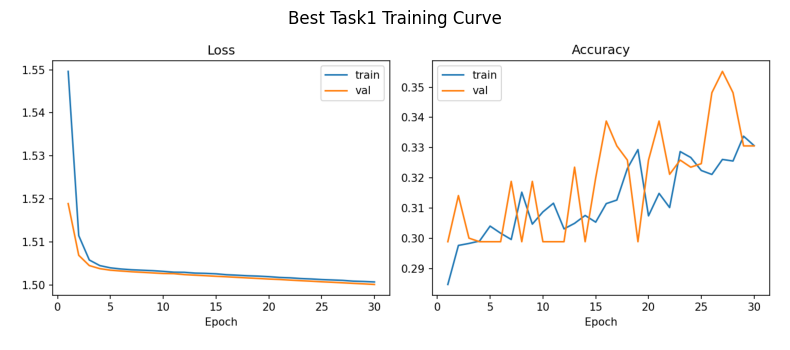

In [4]:
# 3) 最优实验曲线
from PIL import Image
best_path = Path(best_row['path'])
print('Best path:', best_path)
print(json.dumps(json.loads((best_path/'metrics.json').read_text()), indent=2, ensure_ascii=False))
img = Image.open(best_path/'training_curve.png')
plt.figure(figsize=(10,4)); plt.imshow(img); plt.axis('off'); plt.title('Best Task1 Training Curve'); plt.show()